<div dir="rtl" style="text-align:right">

# المحاضرة 1 — ما هي هذه الإشارة، وما هو الـ Receiver؟

> سلسلة: **بناء مستقبِل (Receiver) لنظام Frequency Hopping Continuous Phase Frequency Shift Keying (CPFSK) بطريقة RF Direct Sampling**

## أهداف المحاضرة
بنهاية هذه المحاضرة ستكون قادراً على أن:
1. تشرح بلغة بسيطة معنى: الإشارة (signal)، الحامل (carrier)، البِت (bit)، الإطار (frame)، والقفز الترددي (frequency hopping).
2. تفهم ماذا يفعل نظام **FH-CPFSK**.
3. تُولّد الموجة المرجعية وتراها في **الزمن (time)** و**الطيف (spectrum)** و**الطيف الزمني (spectrogram)**.
4. ترسم خريطة الطريق لسلسلة استقبال (receiver chain) سنبنيها على مدى عشر محاضرات.


</div>

<div dir="rtl" style="text-align:right">

## 1. الفكرة ببساطة: ما هو نظام الاتصالات؟

تخيّل أنك تريد إرسال كلمة إلى صديق يقف بعيداً. فتتفق معه على شفرة: نغمة عالية تعني `1` ونغمة منخفضة تعني `0`. ثم تُحوّل كلمتك إلى سلسلة من الأصفار والآحاد، وتُطلق النغمات واحدة تلو الأخرى.

هذا بالضبط ما يفعله نظام الاتصالات الراديوي، مع فارقين:
- بدل الصوت، نستخدم **موجة كهرومغناطيسية** ذات تردد عالٍ جداً تُسمى **الحامل (carrier)**. في نظامنا الحامل حوالي **2 جيجاهرتز (2 GHz)**.
- ندسّ المعلومة في الحامل بتغيير إحدى خصائصه (تردده أو طوره أو سعته). هذه العملية تُسمى **التعديل (modulation)**.

**المُرسِل (transmitter / TX)** يحوّل الحروف إلى موجة. **المستقبِل (receiver / RX)** يلتقط الموجة ويعيد استخراج الحروف. مهمتنا في هذه السلسلة هي بناء الـ **receiver**.

</div>

<div dir="rtl" style="text-align:right">

## 2. المصطلحات الأساسية

| المصطلح | المعنى  |
|---|---|
| **bit** | أصغر وحدة معلومة: `0` أو `1`. |
| **bit rate (`Rb`)** | كم بِت نرسل في الثانية. هنا 8 ملايين بِت/ثانية (8 Mbps). |
| **symbol / bit period (`Tb`)** | الزمن المخصّص لبِت واحد = 125 نانوثانية. |
| **carrier** | الموجة الجيبية عالية التردد التي «تحمل» المعلومة. |
| **modulation** | طريقة دسّ المعلومة في الحامل. |
| **FSK** (Frequency-Shift Keying) | تعديل نُمثّل فيه `0` و`1` بترددين مختلفين (نغمتين). |
| **CPFSK** (Continuous-Phase FSK) | نوع من FSK يحافظ على **استمرارية الطور (phase)** عند الانتقال بين النغمتين، فلا توجد «قفزات» مفاجئة تُبدّد الطاقة خارج القناة. |
| **frequency hopping (FH)** | تغيير تردد الحامل من إطار لآخر وفق نمط، بدل البقاء على تردد واحد. |
| **frame** | حزمة بِتات مكتملة تحوي المعلومة زائد بِتات مساعدة للتزامن والتحقق. |
| **dwell** | الفترة الزمنية التي يبقى فيها المُرسِل على قناة (تردد) واحد. هنا كل dwell يحمل إطاراً كاملاً. |

</div>

<div dir="rtl" style="text-align:right">

## 3. الأساسيات: من البِتات إلى الإشارة (توضيح بالرسوم)

قبل الدخول إلى تفاصيل الإطار، نبني الحدس البصري لتحوّل البِتات إلى موجة راديوية عبر خمس خطوات، كل خطوة يليها كودها ورسمها مباشرة. الرسوم تستخدم **ترددات صغيرة توضيحية** (بضع دورات لكل رمز) بدل الترددات الحقيقية (الحامل 2 GHz) حتى تكون مقروءة، والمبدأ واحد.

</div>

<div dir="rtl" style="text-align:right">

### (1) معدل البِت وفترة الرمز

كل بِت يشغل زمناً ثابتاً هو **فترة الرمز `Tb`**، ومعدل البِت هو **`Rb = 1/Tb`**. الرسم يعرض سلسلة بِتات كموجة درجية، مع تعليم فترة رمز واحدة.

</div>

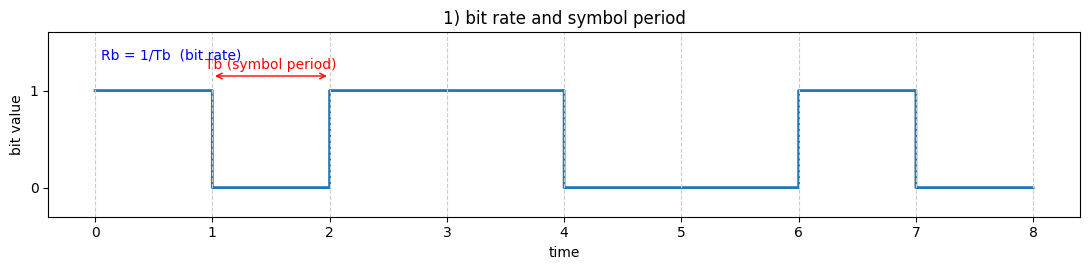

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# (1) bit rate and symbol period -----------------------------------------
bits = [1,0,1,1,0,0,1,0]; Tb = 1.0; fs = 2000
t = np.arange(0, len(bits)*Tb, 1/fs)
idx = np.clip((t//Tb).astype(int), 0, len(bits)-1)
bwave = np.array(bits)[idx]

plt.figure(figsize=(11,2.8))
plt.plot(t, bwave, drawstyle='steps-post', lw=2)
for k in range(len(bits)+1): plt.axvline(k*Tb, color='0.8', ls='--', lw=0.8)
plt.annotate('', xy=(1,1.15), xytext=(2,1.15), arrowprops=dict(arrowstyle='<->', color='r'))
plt.text(1.5, 1.22, 'Tb (symbol period)', color='r', ha='center')
plt.text(0.05, 1.32, 'Rb = 1/Tb  (bit rate)', color='b')
plt.yticks([0,1]); plt.ylim(-0.3,1.6); plt.xlabel('time'); plt.ylabel('bit value')
plt.title('1) bit rate and symbol period'); plt.tight_layout(); plt.show()

<div dir="rtl" style="text-align:right">

### (2) الحامل (carrier)

الحامل موجة جيبية عالية التردد `cos(2π·f_c·t)` هي «الناقل» الذي ندسّ فيه المعلومة. نستخدم هنا تردداً صغيراً توضيحياً (5 دورات لكل رمز) بدل 2 GHz الحقيقي. كذلك نعرض **طيفه (FFT)** فيظهر كخطّ واحد عند `fc`.

</div>

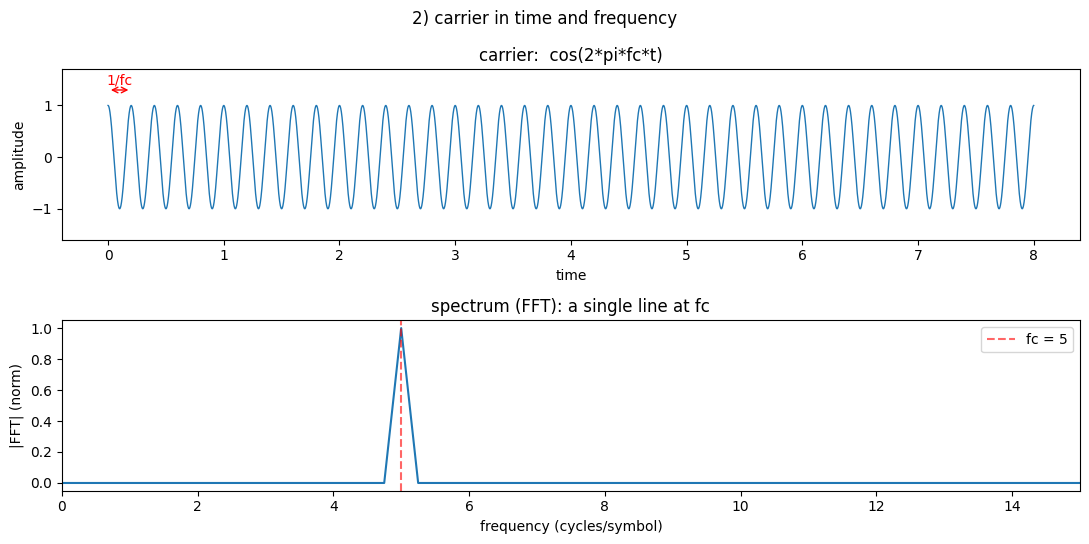

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# (2) carrier + its spectrum ---------------------------------------------
Tb = 1.0; fs = 2000; t = np.arange(0, 8*Tb, 1/fs)
fc = 5/Tb                      # 5 cycles per symbol (illustrative; real carrier = 2 GHz)
carrier = np.cos(2*np.pi*fc*t)

fig, ax = plt.subplots(2, 1, figsize=(11, 5.5))
ax[0].plot(t, carrier, lw=1)
ax[0].annotate('', xy=(0,1.3), xytext=(1/fc,1.3), arrowprops=dict(arrowstyle='<->', color='r'))
ax[0].text(0.5/fc, 1.4, '1/fc', color='r', ha='center')
ax[0].set_ylim(-1.6,1.7); ax[0].set_xlabel('time'); ax[0].set_ylabel('amplitude')
ax[0].set_title('carrier:  cos(2*pi*fc*t)')

N = len(carrier)
S = np.abs(np.fft.rfft(carrier*np.hanning(N)))
f = np.fft.rfftfreq(N, 1/fs)
ax[1].plot(f, S/S.max())
ax[1].axvline(fc, color='r', ls='--', alpha=0.6, label=f'fc = {fc:.0f}')
ax[1].set_xlim(0, 15); ax[1].set_xlabel('frequency (cycles/symbol)'); ax[1].set_ylabel('|FFT| (norm)')
ax[1].set_title('spectrum (FFT): a single line at fc'); ax[1].legend()
plt.suptitle('2) carrier in time and frequency'); plt.tight_layout(); plt.show()

<div dir="rtl" style="text-align:right">

### (3) التعديل (modulation)

ندسّ البِتات في الحامل. أبسط مثال: نمثّل البِت بـ ±1 ونضربه في الحامل (**BPSK**)، فتنطبع البِتات على الموجة. الرسم يبني ذلك من الأعلى للأسفل: الرسالة (±1) ← الحامل ← حاصل الضرب.

</div>

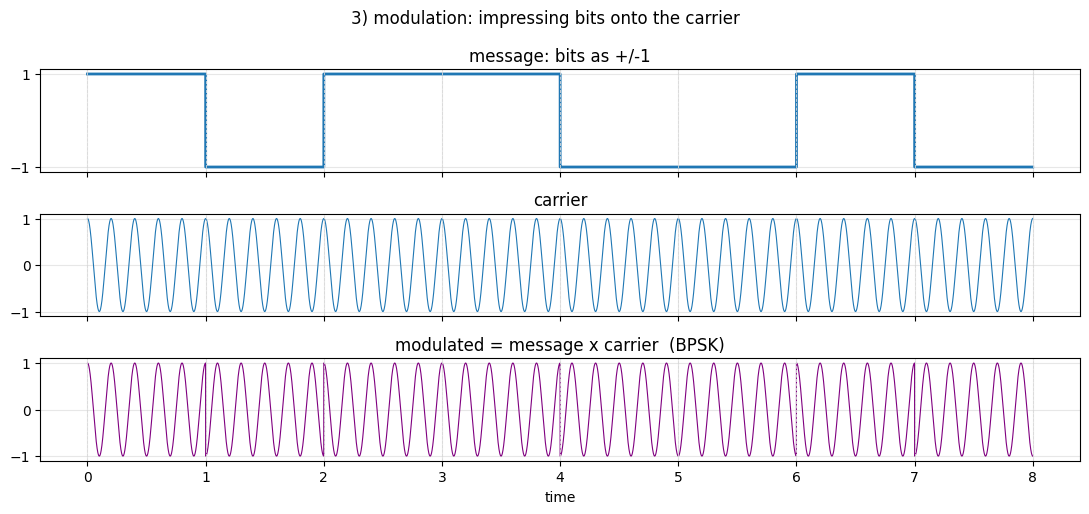

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# (3) modulation = message (bits as +/-1) x carrier  (BPSK example) -------
bits = [1,0,1,1,0,0,1,0]; Tb = 1.0; fs = 2000; fc = 5/Tb
t = np.arange(0, len(bits)*Tb, 1/fs)
idx = np.clip((t//Tb).astype(int), 0, len(bits)-1)
a = 2*np.array(bits)[idx] - 1        # bits mapped to +/-1
carrier = np.cos(2*np.pi*fc*t)
mod = a*carrier

fig, ax = plt.subplots(3,1, figsize=(11,5.2), sharex=True)
ax[0].plot(t, a, drawstyle='steps-post', lw=2); ax[0].set_title('message: bits as +/-1'); ax[0].set_yticks([-1,1])
ax[1].plot(t, carrier, lw=0.8);                 ax[1].set_title('carrier')
ax[2].plot(t, mod, lw=0.8, color='purple');     ax[2].set_title('modulated = message x carrier  (BPSK)')
for a_ in ax:
    for k in range(len(bits)+1): a_.axvline(k*Tb, color='0.85', ls='--', lw=0.6)
    a_.grid(alpha=0.3)
ax[2].set_xlabel('time')
plt.suptitle('3) modulation: impressing bits onto the carrier'); plt.tight_layout(); plt.show()

<div dir="rtl" style="text-align:right">

### (4) FSK

نظامنا لا يضرب في الحامل بل **يغيّر تردده**: نغمة عالية للبِت `1` ونغمة منخفضة للبِت `0` بسعة ثابتة. في FSK البسيط يُعاد ضبط الطور مع كل بِت، فتظهر **قفزات** عند حدود البِتات.

</div>

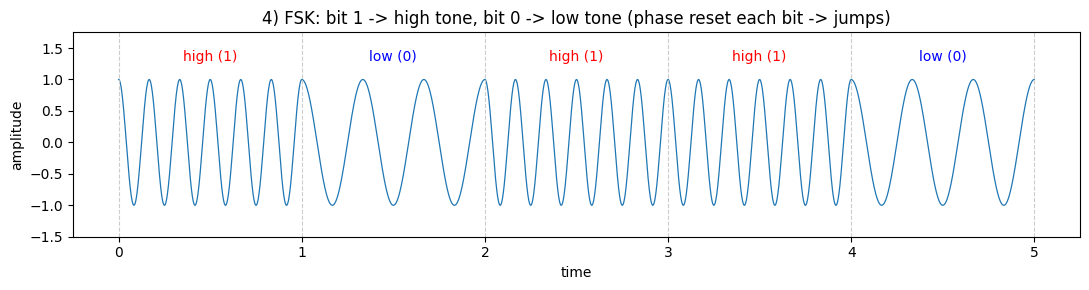

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# (4) FSK: switch frequency per bit, phase reset each bit ------------------
bits = [1,0,1,1,0]; Tb = 1.0; fs = 2000
f_hi, f_lo = 6/Tb, 3/Tb           # bit 1 -> high tone, bit 0 -> low tone
disc = np.concatenate([np.cos(2*np.pi*(f_hi if b else f_lo)*np.arange(0,Tb,1/fs)) for b in bits])
t = np.arange(len(disc))/fs
plt.figure(figsize=(11,3))
plt.plot(t, disc, lw=0.9)
for k in range(len(bits)+1): plt.axvline(k*Tb, color='0.8', ls='--', lw=0.8)
for k,b in enumerate(bits):
    plt.text(k*Tb+0.5, 1.3, ('high' if b else 'low')+f' ({b})', ha='center',
             color=('r' if b else 'b'))
plt.ylim(-1.5,1.75); plt.xlabel('time'); plt.ylabel('amplitude')
plt.title('4) FSK: bit 1 -> high tone, bit 0 -> low tone (phase reset each bit -> jumps)')
plt.tight_layout(); plt.show()

<div dir="rtl" style="text-align:right">

### (5) CPFSK

في **CPFSK** نحمل الطور عبر حدود البِتات (`phase = cumsum(f_inst)`)، فتصير الموجة **ملساء** بلا قفزات — وهذا يقلّل التسرّب الطيفي إلى القنوات المجاورة، وهو تعديل نظامنا. الرسم يقارن FSK وCPFSK ويُظهر مسار الطور المتصل.

</div>

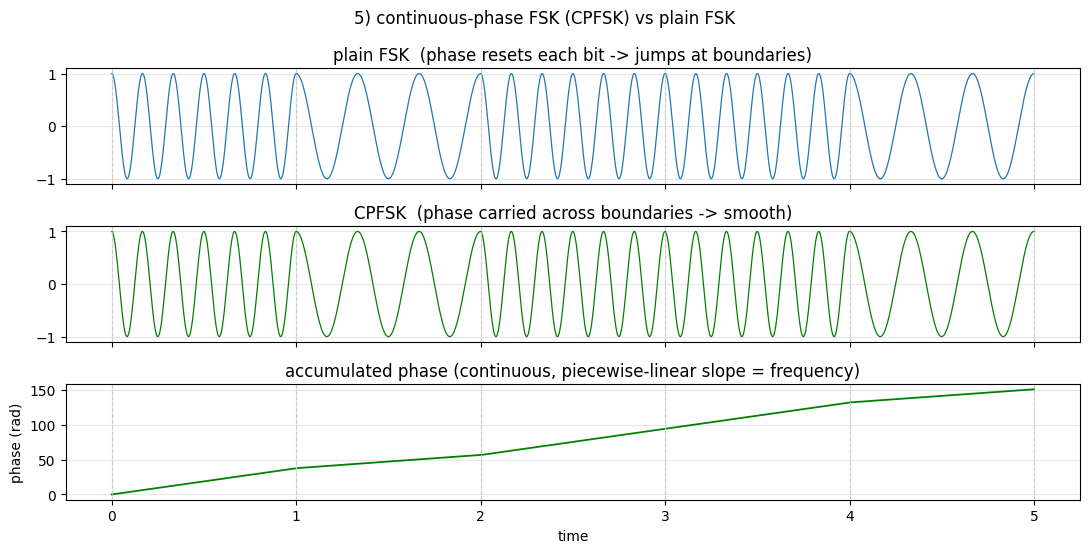

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# (5) continuous-phase FSK vs plain FSK -----------------------------------
bits = [1,0,1,1,0]; Tb = 1.0; fs = 2000; nps = int(Tb*fs)
f_hi, f_lo = 6/Tb, 3/Tb
finst = np.repeat([f_hi if b else f_lo for b in bits], nps)   # per-sample frequency
phase = 2*np.pi*np.cumsum(finst)/fs                           # continuous phase
cpfsk = np.cos(phase)
disc  = np.concatenate([np.cos(2*np.pi*(f_hi if b else f_lo)*np.arange(0,Tb,1/fs)) for b in bits])
t = np.arange(len(cpfsk))/fs

fig, ax = plt.subplots(3,1, figsize=(11,5.6), sharex=True)
ax[0].plot(t, disc,  lw=0.9);              ax[0].set_title('plain FSK  (phase resets each bit -> jumps at boundaries)')
ax[1].plot(t, cpfsk, lw=0.9, color='green'); ax[1].set_title('CPFSK  (phase carried across boundaries -> smooth)')
ax[2].plot(t, phase, lw=1.3, color='green'); ax[2].set_title('accumulated phase (continuous, piecewise-linear slope = frequency)')
for a_ in ax:
    for k in range(len(bits)+1): a_.axvline(k*Tb, color='0.8', ls='--', lw=0.8)
    a_.grid(alpha=0.3)
ax[2].set_xlabel('time'); ax[2].set_ylabel('phase (rad)')
plt.suptitle('5) continuous-phase FSK (CPFSK) vs plain FSK'); plt.tight_layout(); plt.show()

<div dir="rtl" style="text-align:right">

#### تكبير عند حدود البِتات: القفزة مقابل السلاسة

نكبّر على حدّ بِت واحد لنرى الفرق مباشرة: في FSK البسيط **يقفز الطور** (وتنكسر الموجة) عند الحدّ، بينما في CPFSK **يمرّ الطور بسلاسة** فتبقى الموجة متصلة.

</div>

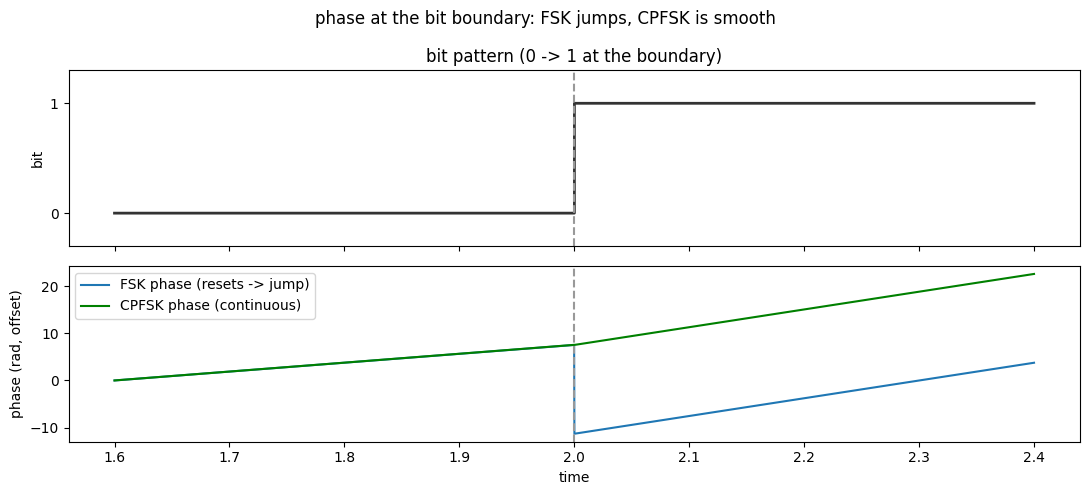

In [6]:
import numpy as np
import matplotlib.pyplot as plt

bits = [1,0,1,1,0]; Tb = 1.0; fs = 4000; nps = int(Tb*fs)
f_hi, f_lo = 6/Tb, 3/Tb
finst = np.repeat([f_hi if b else f_lo for b in bits], nps)
cp_phase = 2*np.pi*np.cumsum(finst)/fs                 # CPFSK: continuous phase
fsk_phase = np.concatenate([2*np.pi*(f_hi if b else f_lo)*np.arange(nps)/fs for b in bits])  # plain FSK: resets each bit
t = np.arange(len(cp_phase))/fs
bpat = np.array(bits)[np.clip((t//Tb).astype(int), 0, len(bits)-1)]   # bit pattern

lo, hi = int(1.6*nps), int(2.4*nps)     # zoom around the boundary at t = 2
fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax[0].plot(t[lo:hi], bpat[lo:hi], drawstyle='steps-post', lw=2, color='0.2')
ax[0].axvline(2.0, color='0.6', ls='--'); ax[0].set_yticks([0,1]); ax[0].set_ylim(-0.3,1.3)
ax[0].set_ylabel('bit'); ax[0].set_title('bit pattern (0 -> 1 at the boundary)')
ax[1].plot(t[lo:hi], fsk_phase[lo:hi]-fsk_phase[lo], color='C0',    label='FSK phase (resets -> jump)')
ax[1].plot(t[lo:hi], cp_phase[lo:hi]-cp_phase[lo],   color='green', label='CPFSK phase (continuous)')
ax[1].axvline(2.0, color='0.6', ls='--'); ax[1].legend(loc='upper left')
ax[1].set_xlabel('time'); ax[1].set_ylabel('phase (rad, offset)')
plt.suptitle('phase at the bit boundary: FSK jumps, CPFSK is smooth'); plt.tight_layout(); plt.show()

<div dir="rtl" style="text-align:right">

#### أثر استمرارية الطور على التسرّب الطيفي

القفزات في FSK البسيط تُنتج **فصوصاً جانبية أعلى** تتسرّب إلى القنوات المجاورة. أما CPFSK بطوره المتصل فينحدر طيفه **أسرع** خارج الحزمة، فيقلّ التسرّب — ولهذا يعتمده نظامنا. نقارن الطيفين لسلسلة بِتات عشوائية طويلة:

</div>

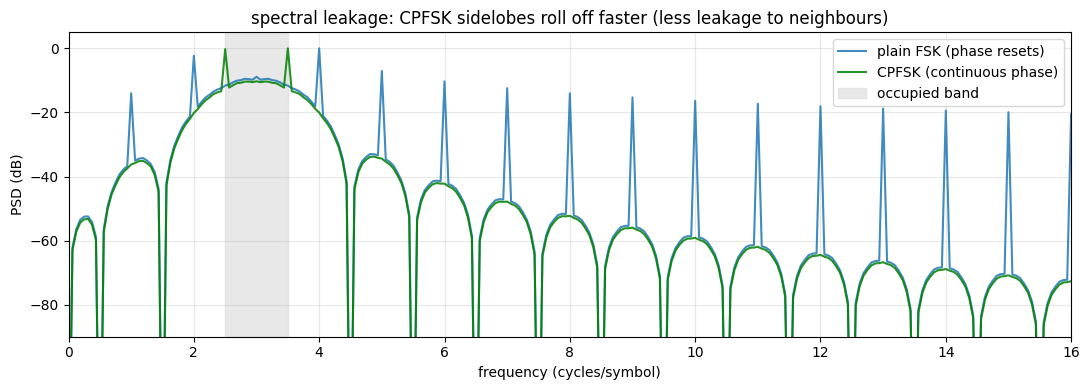

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

rng = np.random.default_rng(0)
Tb = 1.0; fs = 64; nps = int(Tb*fs); f_hi, f_lo = 3.5, 2.5   # tone separation = Rb (h = 1)
bits = rng.integers(0, 2, 4000)
finst = np.repeat([f_hi if b else f_lo for b in bits], nps)
cp   = np.cos(2*np.pi*np.cumsum(finst)/fs)                                  # CPFSK
disc = np.concatenate([np.cos(2*np.pi*(f_hi if b else f_lo)*np.arange(nps)/fs) for b in bits])  # plain FSK

f, Pd = sig.welch(disc, fs=fs, nperseg=1024, window='boxcar')
_, Pc = sig.welch(cp,   fs=fs, nperseg=1024, window='boxcar')
Pd = 10*np.log10(Pd/Pd.max()+1e-15); Pc = 10*np.log10(Pc/Pc.max()+1e-15)

plt.figure(figsize=(11,4))
plt.plot(f, Pd, label='plain FSK (phase resets)', alpha=0.85)
plt.plot(f, Pc, label='CPFSK (continuous phase)', color='green', alpha=0.85)
plt.axvspan(2.5, 3.5, color='0.85', alpha=0.6, label='occupied band')
plt.xlim(0, 16); plt.ylim(-90, 5)
plt.xlabel('frequency (cycles/symbol)'); plt.ylabel('PSD (dB)')
plt.title('spectral leakage: CPFSK sidelobes roll off faster (less leakage to neighbours)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

<div dir="rtl" style="text-align:right">

## 4. بنية الرسالة (Message structure)

كل dwell يحمل إطاراً واحداً كاملاً طوله **96 بِت**. لماذا إطار كامل مستقل في كل قفزة؟ لأن المستقبِل **يُعيد الضبط من الصفر** عند كل قفزة (قناة جديدة): يعيد ضبط الكسب (AGC — Automatic Gain Control)، وتزامن الرموز (symbol timing)، ومحاذاة الإطار (frame alignment).

<div dir="ltr" style="text-align:left">

```
┌──────────────┬──────────┬──────────┬───────────────┬──────────┐
│  PREAMBLE    │   SFD    │   HDR    │    PAYLOAD    │   CRC    │
│     8 b      │    5 b   │    3 b   │      64 b     │   16 b   │
└──────────────┴──────────┴──────────┴───────────────┴──────────┘
```

</div>

| الحقل | الطول | الوظيفة |
|---|---|---|
| **PREAMBLE** | 8 bit | نمط متبادل `1010…` يستخدمه المستقبِل لضبط الكسب والتوقيت. |
| **SFD** (Start Frame Delimiter) | 5 bit | متتالية **Barker-5**: `11101`. علامة «طلقة البداية» التي تحدّد بدء الإطار بدقة. |
| **HDR** (Header) | 3 bit | رقم تسلسلي (sequence number) 1..6 لإعادة ترتيب الرسائل. |
| **PAYLOAD** | 64 bit | 8 حروف ASCII، كل حرف 8 بِت، بترتيب **MSB أولاً**. |
| **CRC** (Cyclic Redundancy Check) | 16 bit | **CRC-16** للتحقق من سلامة HDR+PAYLOAD. |

طول الإطار 96 بِت × 125 ns = **12 µs** لكل dwell. سنعود لكل حقل بالتفصيل في محاضرات لاحقة.

</div>

<div dir="rtl" style="text-align:right">

## 5. نظامنا تحديداً: FH-CPFSK

 النظام هو مُرسِل **Frequency Hopping-CPFSK** يرسل ست رسائل، كل رسالة 8 حروف (characters). خصائصه الأساسية:

- **التعديل:** CPFSK بمُعامِل تعديل (modulation index) **h = 1**.
- **معدل البِت:** 8 Mbps، أي `Tb = 125 ns`.
- **القفز الترددي:** 6 قنوات (channels) حول 2 GHz، المسافة بينها 18 MHz.
- كل رسالة تُرسَل على قناة تُختار **عشوائياً** من مجموعة القفز (hop set).
- الإشارة الناتجة **حقيقية (real-valued)** — أي جهد واحد يتغير مع الزمن، وهو ما يراه محوّل ADC (Analog-to-Digital Converter) حين يأخذ عيّنات مباشرة من الهوائي.

### لماذا h = 1 مهم؟
مُعامِل التعديل يُعرَّف بالعلاقة التالية (حيث $\Delta f$ هو انزياح التردد عن الحامل):

<div dir="ltr" style="text-align:left">

$$ h = 2 \cdot \Delta f \cdot T_b $$

</div>

وهنا:

<div dir="ltr" style="text-align:left">

$$ \Delta f = R_b/2 = 4\text{ MHz} $$

</div>

فيكون:

<div dir="ltr" style="text-align:left">

$$ h = 2 \times 4\text{ MHz} \times 125\text{ ns} = 1 $$

</div>

قيمة `h = 1` تجعل النغمتين **متعامدتين (orthogonal)** ومتباعدتين بمقدار `Rb` بالضبط (8 MHz). هذه هي حالة **Sunde's FSK**، وميزتها أنها تسمح بكشف غير متجانس (noncoherent detection) بسيط وقوي — وهو ما سنعتمده لاحقاً في الـ demodulator.

</div>

<div dir="rtl" style="text-align:right">

## 6. شكل الإشارة؟

سنستخدم `fhcpfsk.py` (موجودة بجوار هذا الدفتر) لتوليد الموجة ونتحقق منها خطوة بخطوة في المحاضرات القادمة. أما الآن فسنستخدمها فقط لنشاهد كيف تبدو الإشارة.

</div>

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import fhcpfsk as fh

# system parameters
print(f"bit rate   Rb  = {fh.Rb/1e6:.0f} Mbps")
print(f"bit period Tb  = {fh.Tb*1e9:.0f} ns")
print(f"sample rate fs = {fh.FS/1e9:.2f} GHz   (sps = {fh.SPS})")
print(f"hop centre fc0 = {fh.FC0/1e9:.1f} GHz")
print(f"channels       = {fh.NCHAN}, spacing = {fh.HOP_SPACING/1e6:.0f} MHz")
print(f"hop set (GHz)  = {np.round(fh.hop_set()/1e9,4)}")
print(f"samples/dwell  = {fh.SAMPLES_PER_FRAME}")


bit rate   Rb  = 8 Mbps
bit period Tb  = 125 ns
sample rate fs = 8.19 GHz   (sps = 1024)
hop centre fc0 = 2.0 GHz
channels       = 6, spacing = 18 MHz
hop set (GHz)  = [1.955 1.973 1.991 2.009 2.027 2.045]
samples/dwell  = 98304


In [9]:
# generate the full waveform: six messages, random channels, dead time at both ends
messages = ['HELLO123','RADIO_RX','FH-CPFSK','DIRECT!!','SAMPLING','LECTURE0']
wave, info = fh.transmit(messages, seed=42)

print("n samples   :", wave.shape[0])
print("transmission duration   : %.2f µs" % (len(wave)/fh.FS*1e6))
print("actual channels:", info['channels'])
print("start of each dwell:", info['dwell_starts'])


n samples   : 949926
transmission duration   : 115.96 µs
actual channels: [3, 2, 5, 4, 1, 0]
start of each dwell: [192404, 290708, 389012, 487316, 585620, 683924]


<div dir="rtl" style="text-align:right">

### (أ) في الزمن (time domain)
نرسم الموجة **بالكامل** على محور الزمن، فتظهر بنية الدفقات: صمت (dead time) في الطرفين وست dwells متلاصقة في الوسط.

</div>

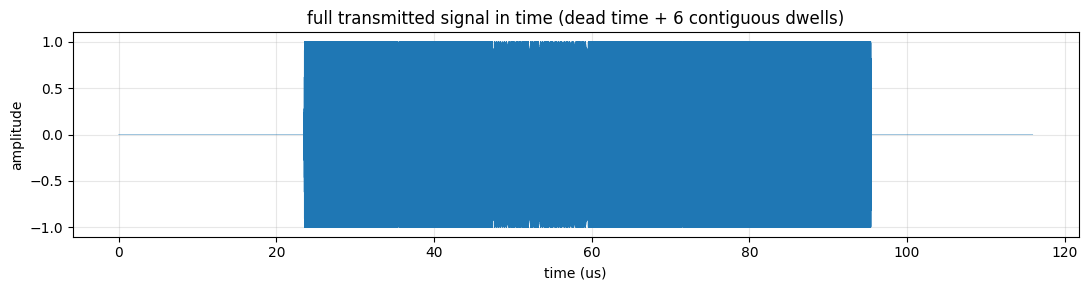

In [10]:
t = np.arange(len(wave)) / fh.FS
plt.figure(figsize=(11,3))
plt.plot(t*1e6, wave, lw=0.3)
plt.xlabel("time (us)"); plt.ylabel("amplitude")
plt.title("full transmitted signal in time (dead time + 6 contiguous dwells)")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

<div dir="rtl" style="text-align:right">

### (ب) الطيف (spectrum)
تحويل فورييه (FFT) يُظهر أين تتركّز الطاقة على محور التردد. نتوقّع طاقة موزّعة على القنوات الست بين 1.955 و2.045 GHz — أثر القفز الترددي عبر الإرسال بأكمله.

</div>

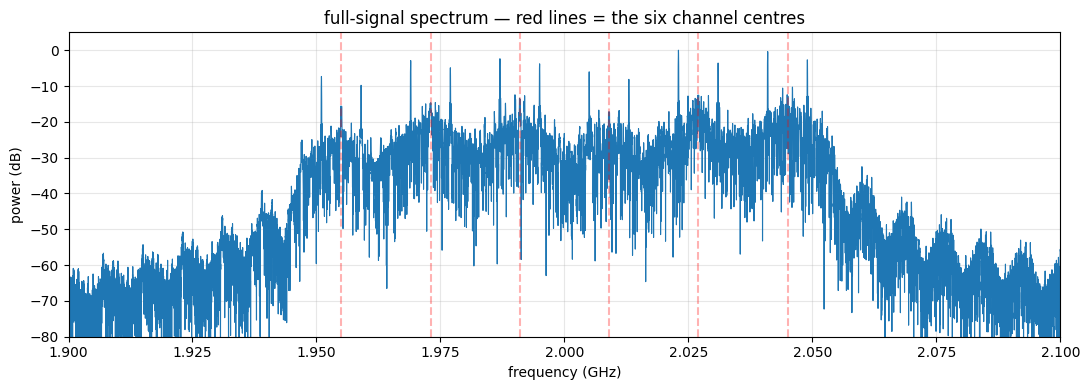

In [11]:
N = len(wave)
S = np.abs(np.fft.rfft(wave * np.hanning(N)))
f = np.fft.rfftfreq(N, 1/fh.FS)
Sdb = 20*np.log10(S/ S.max() + 1e-12)

plt.figure(figsize=(11,4))
plt.plot(f/1e9, Sdb, lw=0.8)
for fc in fh.hop_set():
    plt.axvline(fc/1e9, color='r', ls='--', alpha=0.3)
plt.xlim(1.90, 2.10); plt.ylim(-80, 5)
plt.xlabel("frequency (GHz)"); plt.ylabel("power (dB)")
plt.title("full-signal spectrum — red lines = the six channel centres")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


<div dir="rtl" style="text-align:right">

### (ج) الطيف الزمني (spectrogram)
الطيف وحده يخبرنا *أين* الطاقة على محور التردد، لكنه لا يخبرنا *متى*. الـ **spectrogram** يعرض التردد على المحور الرأسي والزمن على المحور الأفقي، فنرى كل قفزة (hop) كصندوق طاقة على قناة معينة في لحظة معينة. هذه الصورة هي جوهر مشكلة الاستقبال: **على أي قناة، وفي أي زمن، ظهرت كل قفزة؟**

</div>

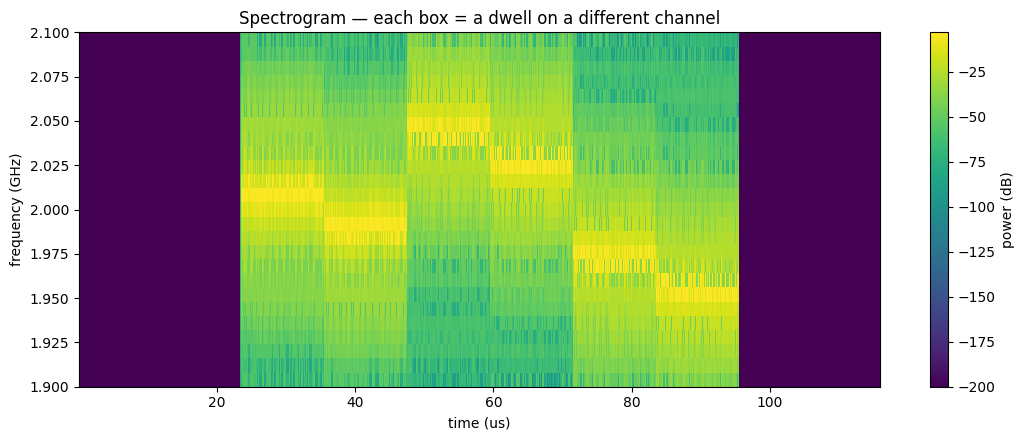

actual channels in time order: [3, 2, 5, 4, 1, 0]


In [12]:
from scipy import signal as sig
f2, t2, Sxx = sig.spectrogram(wave, fs=fh.FS, nperseg=1024, noverlap=512,
                              scaling='spectrum')
plt.figure(figsize=(11,4.5))
plt.pcolormesh(t2*1e6, f2/1e9, 10*np.log10(Sxx+1e-20), shading='auto')
plt.ylim(1.90, 2.10)
plt.xlabel("time (us)"); plt.ylabel("frequency (GHz)")
plt.title("Spectrogram — each box = a dwell on a different channel")
plt.colorbar(label="power (dB)")
plt.tight_layout(); plt.show()

print("actual channels in time order:", info['channels'])


<div dir="rtl" style="text-align:right">

لاحظ في الـ spectrogram:
- **الصمت في البداية والنهاية** = الـ dead time.
- **ست صناديق متتالية** = القفزات الست، كل واحدة على تردد قد يختلف.
- ارتفاع كل صندوق (عرض الحزمة) ~ 16 MHz، وهو عرض الحزمة المشغول لكل dwell (`2·Rb`).

المستقبِل لا يعرف مسبقاً ترتيب القنوات؛ عليه أن يكتشفه من الإشارة — وهذا موضوع المحاضرة الرابعة.

</div>

<div dir="rtl" style="text-align:right">

## 7. خريطة الطريق: مراحل الـ Receiver

الإشارة تدخل المستقبِل كتيار عيّنات حقيقية عند 8.192 GHz (direct sampling). سنبني سلسلة المعالجة على النحو التالي، وكل محاضرة تُنتج دالة (function) تستوردها التي تليها:

| المحاضرة | المرحلة | المخرَج |
|---|---|---|
| 2 | فهم الـ **sampling** والـ direct RF sampling | أساس نظري |
| 3 | بناء **Transmitter** مرجعي | `transmit()` |
| 4 | **Detection & Channelization**: أين ومتى القفزات | `(start, stop, channel)` |
| 5 | **Digital Downconversion (DDC)** إلى baseband | إشارة baseband مركّبة |
| 6 | **Demodulation** (noncoherent energy detection) | بِتات |
| 7 | **Synchronization**: AGC، التوقيت، إزاحة التردد | عيّنات متزامنة |
| 8 | **Frame sync** عبر الـ SFD | موضع بداية الإطار |
| 9 | **Decode + CRC** | رسالة موثّقة |
| 10 | **Receiver كامل** + قياس الأداء (BER — Bit Error Rate) | `receive()` |

في المحاضرة القادمة نتعمّق في السؤال الأهم لهذا المعمار: كيف نأخذ عيّنات من إشارة عند 2 GHz، وماذا يعني «RF direct sampling»؟

</div>

<div dir="rtl" style="text-align:right">

---
### تمارين
1. غيّر `seed` في `fh.transmit` وأعد رسم الـ spectrogram. هل تغيّر ترتيب القنوات؟
2. جرّب `nperseg=256` ثم `nperseg=4096` في الـ spectrogram. لاحظ المقايضة (trade-off) بين الدقة الزمنية والدقة الترددية.
3. من الطيف، احسب المسافة بين أعلى قناة وأدناها. هل تساوي 90 MHz؟

</div>